<a href="https://colab.research.google.com/github/RezeneG/Natural_Language_Processing_MidModule_Assessement/blob/main/NLP_MidModule_Assessement.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
from google.colab import files

print("Please select your Amazon Fine Food Reviews.csv file to upload...")
print("(The file is about 300MB, so this may take 1-2 minutes)")

uploaded = files.upload()

print("\n✓ Upload complete!")
print("Uploaded files:")
for filename in uploaded.keys():
    print(f"  - {filename}")
    print(f"    Size: {len(uploaded[filename]):,} bytes")

Please select your Amazon Fine Food Reviews.csv file to upload...
(The file is about 300MB, so this may take 1-2 minutes)


Saving Amazon Fine Food Reviews.csv to Amazon Fine Food Reviews.csv

✓ Upload complete!
Uploaded files:
  - Amazon Fine Food Reviews.csv
    Size: 300,904,694 bytes


In [6]:
import os
print("Current directory contents:")
for file in os.listdir():
    print(f"  - {file}")

Current directory contents:
  - .config
  - Amazon Fine Food Reviews.csv
  - sample_data


In [7]:
import pandas as pd

# Find the CSV file
csv_files = [f for f in os.listdir() if f.endswith('.csv')]
print(f"CSV files found: {csv_files}")

if csv_files:
    filename = csv_files[0]
    print(f"\nLoading {filename}...")
    df = pd.read_csv(filename)
    print(f"✓ Loaded successfully!")
    print(f"  - Rows: {df.shape[0]:,}")
    print(f"  - Columns: {df.shape[1]}")
    print(f"\nColumn names:")
    print(df.columns.tolist())
else:
    print("No CSV file found. Please upload the file again.")

CSV files found: ['Amazon Fine Food Reviews.csv']

Loading Amazon Fine Food Reviews.csv...
✓ Loaded successfully!
  - Rows: 568,454
  - Columns: 10

Column names:
['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator', 'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text']


In [8]:
import pandas as pd
import numpy as np
import re
import time
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import NMF, LatentDirichletAllocation
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Download NLTK data
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

# Find and load the CSV file
import os
csv_files = [f for f in os.listdir() if f.endswith('.csv')]
print(f"Found CSV files: {csv_files}")

if csv_files:
    filename = csv_files[0]
    print(f"Loading {filename}...")
    df = pd.read_csv(filename)
    print(f"✓ Loaded {df.shape[0]:,} rows, {df.shape[1]} columns")
    print(f"Columns: {df.columns.tolist()}")
else:
    print("No CSV file found. Please upload the file.")

Found CSV files: ['Amazon Fine Food Reviews.csv']
Loading Amazon Fine Food Reviews.csv...
✓ Loaded 568,454 rows, 10 columns
Columns: ['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator', 'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text']


In [9]:
# Take a random sample to get results quickly
sample_size = 50000  # Using 50,000 for even faster processing
df_sample = df.sample(n=min(sample_size, len(df)), random_state=42)
print(f"Working with {len(df_sample):,} sample reviews")

# Display a sample review
print("\nSample review:")
print(df_sample['Text'].iloc[0][:300])

Working with 50,000 sample reviews

Sample review:
Having tried a couple of other brands of gluten-free sandwich cookies, these are the best of the bunch.  They're crunchy and true to the texture of the other "real" cookies that aren't gluten-free.  Some might think that the filling makes them a bit too sweet, but for me that just means I've satisfi


In [10]:
# Setup
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

# Add common words to remove
additional_stops = {
    'food', 'product', 'amazon', 'review', 'item', 'buy', 'purchase',
    'get', 'would', 'also', 'one', 'even', 'really', 'great', 'good',
    'br', 'like', 'just', 'can', 'will', 'know', 'use', 'time'
}
stop_words.update(additional_stops)

def preprocess_text(text):
    """Clean and preprocess text"""
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)  # Remove punctuation/numbers
    text = re.sub(r'\s+', ' ', text).strip()  # Remove extra spaces
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(token) for token in tokens
              if token not in stop_words and len(token) > 2]
    return ' '.join(tokens)

# Apply preprocessing
print("Preprocessing reviews...")
start = time.time()
df_sample['processed_text'] = df_sample['Text'].astype(str).apply(preprocess_text)

# Remove empty documents
df_sample = df_sample[df_sample['processed_text'].str.strip() != '']
print(f"✓ Preprocessing complete in {time.time()-start:.2f} seconds")
print(f"✓ {len(df_sample):,} documents remaining")

# Show example
print("\nOriginal:")
print(df_sample['Text'].iloc[0][:200])
print("\nProcessed:")
print(df_sample['processed_text'].iloc[0][:200])

Preprocessing reviews...
✓ Preprocessing complete in 14.89 seconds
✓ 50,000 documents remaining

Original:
Having tried a couple of other brands of gluten-free sandwich cookies, these are the best of the bunch.  They're crunchy and true to the texture of the other "real" cookies that aren't gluten-free.  S

Processed:
tried couple brand glutenfree sandwich cooky best bunch theyre crunchy true texture real cooky arent glutenfree might think filling make bit sweet mean ive satisfied sweet tooth sooner chocolate versi


In [11]:
print("Creating Bag-of-Words matrix...")
bow_vectorizer = CountVectorizer(
    max_df=0.95,
    min_df=5,
    max_features=3000  # Reduced for faster processing
)
bow_matrix = bow_vectorizer.fit_transform(df_sample['processed_text'])
print(f"✓ BoW shape: {bow_matrix.shape}")

print("\nCreating TF-IDF matrix...")
tfidf_vectorizer = TfidfVectorizer(
    max_df=0.95,
    min_df=5,
    max_features=3000
)
tfidf_matrix = tfidf_vectorizer.fit_transform(df_sample['processed_text'])
print(f"✓ TF-IDF shape: {tfidf_matrix.shape}")

bow_features = bow_vectorizer.get_feature_names_out()
tfidf_features = tfidf_vectorizer.get_feature_names_out()

Creating Bag-of-Words matrix...
✓ BoW shape: (50000, 3000)

Creating TF-IDF matrix...
✓ TF-IDF shape: (50000, 3000)


In [12]:
def show_topics(model, feature_names, n_words=10):
    """Display top words for each topic"""
    topics = {}
    for idx, topic in enumerate(model.components_):
        top_indices = topic.argsort()[:-n_words-1:-1]
        top_words = [feature_names[i] for i in top_indices]
        topics[f"Topic {idx+1}"] = top_words
        print(f"\nTopic {idx+1}:")
        print(", ".join(top_words))
    return topics

In [13]:
print("="*60)
print("NMF Topic Model")
print("="*60)

n_topics = 5

nmf = NMF(
    n_components=n_topics,
    random_state=42,
    max_iter=500,
    alpha_W=0.1,
    alpha_H=0.1
)

print("Training NMF...")
start = time.time()
nmf.fit(tfidf_matrix)
print(f"✓ NMF training complete in {time.time()-start:.2f} seconds")

print("\nNMF Topics (Top 10 words):")
nmf_topics = show_topics(nmf, tfidf_features)

NMF Topic Model
Training NMF...
✓ NMF training complete in 0.52 seconds

NMF Topics (Top 10 words):

Topic 1:
coffee, tea, taste, flavor, love, dog, make, price, bag, dont

Topic 2:
coffee, tea, taste, flavor, love, cup, make, price, best, dont

Topic 3:
tea, coffee, taste, flavor, love, cup, bag, make, price, drink

Topic 4:
coffee, tea, love, taste, dog, flavor, treat, make, price, cup

Topic 5:
coffee, tea, taste, love, flavor, dog, make, price, treat, cat


In [14]:
print("\n" + "="*60)
print("LDA Topic Model (Online)")
print("="*60)

lda = LatentDirichletAllocation(
    n_components=n_topics,
    random_state=42,
    learning_method='online',
    max_iter=50,
    perp_tol=0.1,
    n_jobs=-1
)

print("Training online LDA...")
start = time.time()
lda.fit(bow_matrix)
print(f"✓ LDA training complete in {time.time()-start:.2f} seconds")

print("\nLDA Topics (Top 10 words):")
lda_topics = show_topics(lda, bow_features)


LDA Topic Model (Online)
Training online LDA...
✓ LDA training complete in 772.78 seconds

LDA Topics (Top 10 words):

Topic 1:
coffee, price, flavor, cup, store, taste, love, find, best, brand

Topic 2:
dog, treat, cat, love, day, eat, year, old, month, dont

Topic 3:
flavor, taste, chip, love, chocolate, make, little, salt, sauce, cooky

Topic 4:
taste, sugar, bar, oil, calorie, snack, ingredient, butter, organic, fat

Topic 5:
tea, taste, water, drink, bag, box, flavor, bottle, make, green


In [15]:
def get_exemplars(model, matrix, df, topic_idx, text_col='Text', n=3):
    """Get top documents for a topic"""
    doc_topic = model.transform(matrix)
    top_docs = doc_topic[:, topic_idx].argsort()[-n:][::-1]

    print(f"\n--- Topic {topic_idx+1} ---")
    for i, idx in enumerate(top_docs):
        text = df.iloc[idx][text_col][:200]
        print(f"{i+1}. {text}...")
        print()

# NMF exemplars
print("\n" + "="*60)
print("NMF - Exemplar Documents")
print("="*60)
for i in range(n_topics):
    get_exemplars(nmf, tfidf_matrix, df_sample, i)

# LDA exemplars
print("\n" + "="*60)
print("LDA - Exemplar Documents")
print("="*60)
for i in range(n_topics):
    get_exemplars(lda, bow_matrix, df_sample, i)


NMF - Exemplar Documents

--- Topic 1 ---
1. Love, love, love!  The smell of the coffee packs!  When I got this and opened it, honestly, the aroma was just so amazing, it is one of the best smelling coffees I have ever smelled!<br /><br />  If o...

2. Love, love, love!  The smell of the coffee packs!  When I got this and opened it, honestly, the aroma was just so amazing, it is one of the best smelling coffees I have ever smelled!<br /><br />  If o...

3. I nevr tasted 100% Ethiopian Yirgacheffe before, so I wasn't sure what to expect. But this really surprised me. There was none. No taste. Just tan water.  When I put the packet into the pod brewer, wh...


--- Topic 2 ---
1. Love, love, love!  The smell of the coffee packs!  When I got this and opened it, honestly, the aroma was just so amazing, it is one of the best smelling coffees I have ever smelled!<br /><br />  If o...

2. Love, love, love!  The smell of the coffee packs!  When I got this and opened it, honestly, the aroma was

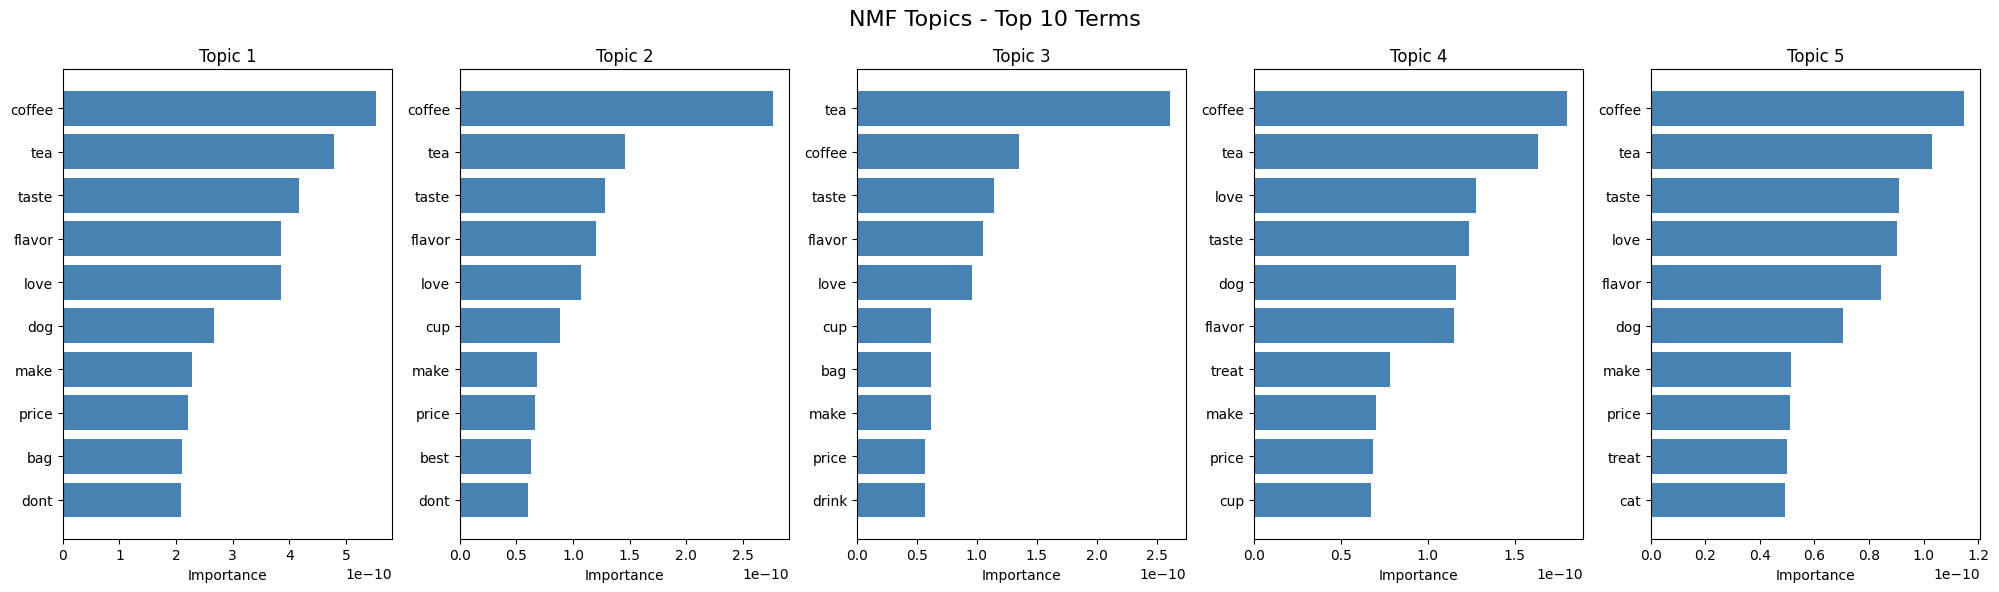

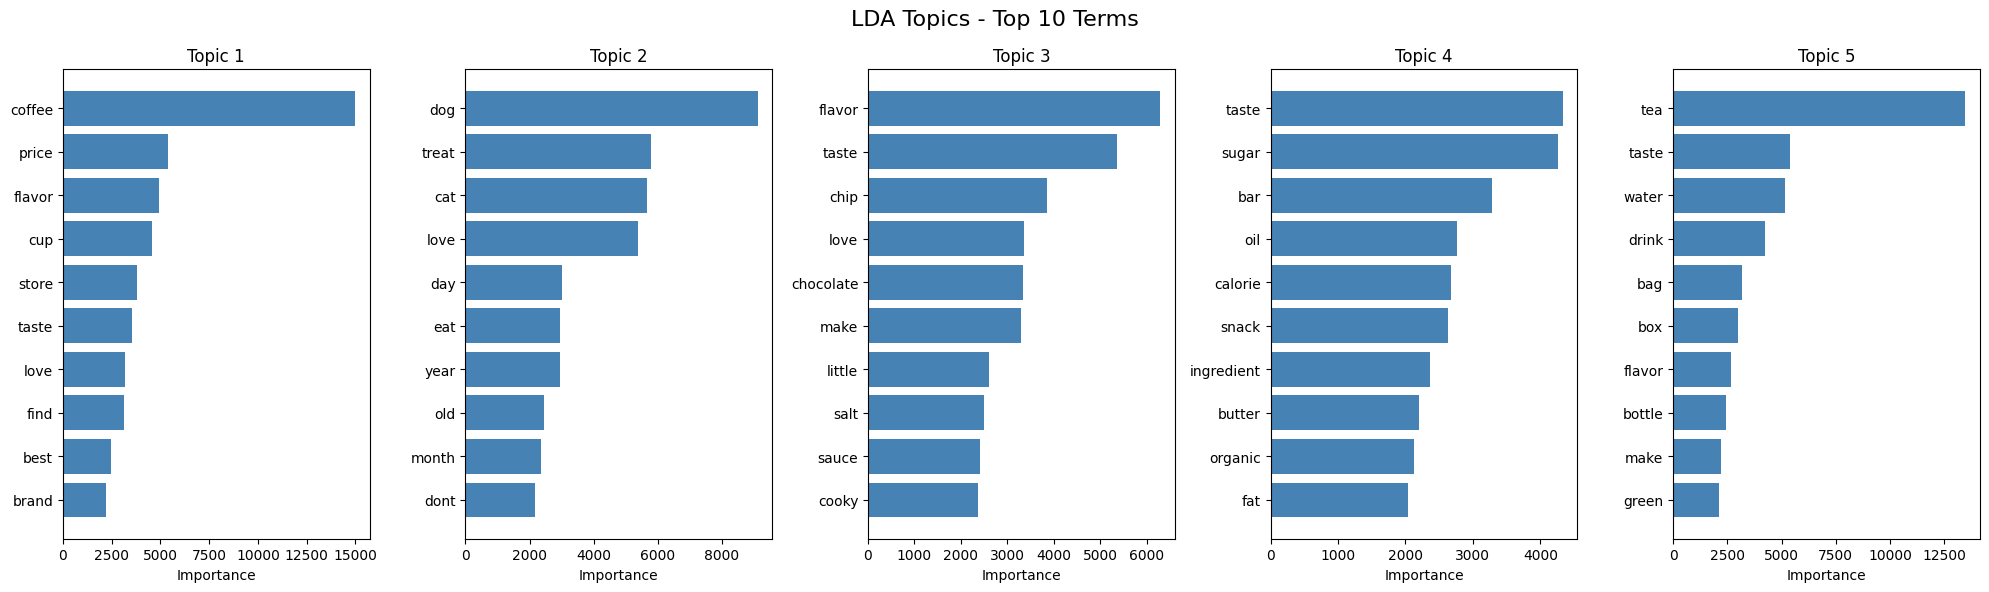

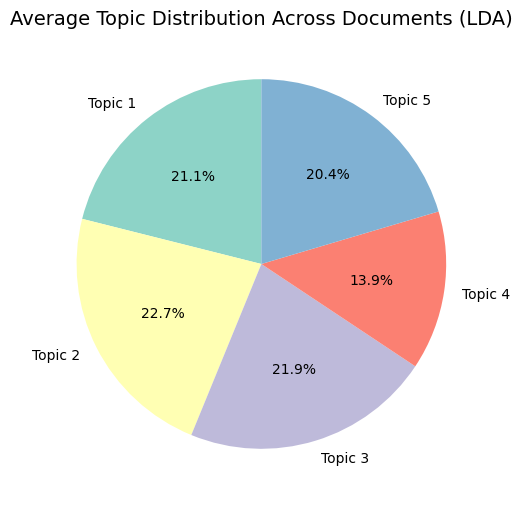

In [16]:
def plot_topics(model, feature_names, title):
    """Create bar plots for topics"""
    fig, axes = plt.subplots(1, n_topics, figsize=(20, 6))
    fig.suptitle(title, fontsize=16)

    for i, topic in enumerate(model.components_):
        top_idx = topic.argsort()[-10:][::-1]
        words = [feature_names[j] for j in top_idx]
        scores = topic[top_idx]

        axes[i].barh(words, scores, color='steelblue')
        axes[i].set_title(f"Topic {i+1}")
        axes[i].invert_yaxis()
        axes[i].set_xlabel('Importance')

    plt.tight_layout()
    plt.show()

# Plot both models
plot_topics(nmf, tfidf_features, "NMF Topics - Top 10 Terms")
plot_topics(lda, bow_features, "LDA Topics - Top 10 Terms")

# Topic distribution
doc_topic_dist = lda.transform(bow_matrix)
avg_dist = doc_topic_dist.mean(axis=0)

plt.figure(figsize=(8, 6))
plt.pie(avg_dist, labels=[f'Topic {i+1}' for i in range(n_topics)],
        autopct='%1.1f%%', startangle=90, colors=plt.cm.Set3(range(n_topics)))
plt.title('Average Topic Distribution Across Documents (LDA)', fontsize=14)
plt.show()

In [17]:
# Create DataFrames for results
nmf_results = []
for topic_name, words in nmf_topics.items():
    nmf_results.append([topic_name, ', '.join(words)])

lda_results = []
for topic_name, words in lda_topics.items():
    lda_results.append([topic_name, ', '.join(words)])

nmf_df = pd.DataFrame(nmf_results, columns=['Topic', 'Top Terms'])
lda_df = pd.DataFrame(lda_results, columns=['Topic', 'Top Terms'])

# Save to CSV
nmf_df.to_csv('nmf_topics.csv', index=False)
lda_df.to_csv('lda_topics.csv', index=False)

print("✓ Results saved to:")
print("  - nmf_topics.csv")
print("  - lda_topics.csv")
print("\n" + "="*60)
print("Summary")
print("="*60)
print(f"Documents processed: {len(df_sample):,}")
print(f"Vocabulary size: {len(bow_features):,}")
print(f"Number of topics: {n_topics}")
print(f"\nNMF topics saved: {len(nmf_df)}")
print(f"LDA topics saved: {len(lda_df)}")

✓ Results saved to:
  - nmf_topics.csv
  - lda_topics.csv

Summary
Documents processed: 50,000
Vocabulary size: 3,000
Number of topics: 5

NMF topics saved: 5
LDA topics saved: 5
